# 02 — Clasificación con DenseNet121
**Tarea:** Clasificación de mamografías en tres clases: `NORM` (0), `Benigno` (1), `Maligno` (2)  
**Arquitectura:** DenseNet121 con Transfer Learning (ImageNet)  
**Estrategia:** K-Fold (k=5) sobre Train+Val → Fine-tuning en dos fases → Evaluación final en Test

## 1. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import DenseNet121_Weights

import cv2
from PIL import Image
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

Dispositivo: cuda


## 2. Rutas y parámetros

In [2]:
DATA_DIR   = Path('../data')
MODELS_DIR = Path('../models')
RESULTS_DIR = Path('../results')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE      = 512        # coincide con el preprocesamiento
BATCH_SIZE    = 16
NUM_CLASSES   = 3
LR_HEAD       = 1e-3       # fase 1: solo cabeza
LR_FULL       = 1e-4       # fase 2: fine-tuning completo
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 20
PATIENCE      = 5
N_FOLDS       = 5

CLASS_NAMES   = ['NORM', 'Benigno', 'Maligno']
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

## 3. Carga de datos desde el preprocesamiento

Recuperamos los IDs y etiquetas generados en `01_preprocesamiento.ipynb`.  
Separamos el **test set** (intocable) del **pool train+val** sobre el que haremos K-Fold.

In [3]:
def build_dataframe(split: str) -> pd.DataFrame:
    """Construye DataFrame {image_id, img_path, label} para un split dado."""
    images_dir = DATA_DIR / split / 'images'
    labels_dir = DATA_DIR / split / 'labels'
    records = []
    for img_path in sorted(images_dir.glob('*.png')):
        img_id     = img_path.stem
        label_file = labels_dir / f'{img_id}_label.npy'
        label      = int(np.load(label_file)) if label_file.exists() else 0
        records.append({'image_id': img_id, 'img_path': str(img_path), 'label': label})
    return pd.DataFrame(records)


df_train = build_dataframe('train')
df_val   = build_dataframe('val')
df_test  = build_dataframe('test')

# Pool train+val para K-Fold
df_trainval = pd.concat([df_train, df_val], ignore_index=True)

print(f'Train+Val: {len(df_trainval)} | Test (fijo): {len(df_test)}')
print('\nDistribución Train+Val:')
print(df_trainval['label'].value_counts().rename(index=dict(enumerate(CLASS_NAMES))))
print('\nDistribución Test:')
print(df_test['label'].value_counts().rename(index=dict(enumerate(CLASS_NAMES))))

Train+Val: 408 | Test (fijo): 102

Distribución Train+Val:
label
NORM       190
Benigno    115
Maligno    103
Name: count, dtype: int64

Distribución Test:
label
NORM       45
Benigno    31
Maligno    26
Name: count, dtype: int64


## 4. Dataset y Transforms

El augmentation geométrico se aplica **solo en train** y en tiempo real,  
generando variaciones distintas en cada época.

In [4]:
# Augmentation en tiempo real para el split de entrenamiento
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Validación y test: solo normalización (sin augmentation)
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


class MammographyDataset(Dataset):
    """
    Dataset de mamografías para clasificación.
    Las imágenes vienen en escala de grises (1 canal) del preprocesamiento;
    se replican a 3 canales para compatibilidad con DenseNet121 preentrenado.
    El resize ya fue aplicado en el preprocesamiento (512×512).
    """
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('L')      # escala de grises
        img = Image.merge('RGB', [img, img, img])            # → 3 canales
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row['label'], dtype=torch.long)


def make_loaders(df_tr: pd.DataFrame, df_vl: pd.DataFrame):
    """Crea DataLoaders para un par train/val."""
    tr = DataLoader(MammographyDataset(df_tr, train_transform),
                    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
    vl = DataLoader(MammographyDataset(df_vl, val_test_transform),
                    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    return tr, vl


# DataLoader de test — se usa solo en la evaluación final
test_loader = DataLoader(
    MammographyDataset(df_test, val_test_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

## 5. Modelo — DenseNet121 con Transfer Learning

Fine-tuning en **dos fases**:
- **Fase 1:** Backbone congelado, solo se entrena la cabeza clasificadora.
- **Fase 2:** Red completa descongelada con lr bajo para adaptar al dominio mamográfico.

In [5]:
def build_densenet121(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    model = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    return model

## 6. Funciones de entrenamiento y evaluación

In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labs in tqdm(loader, desc='  train', leave=False):
        imgs, labs = imgs.to(device), labs.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labs).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_preds, all_labels = [], [], []
    for imgs, labs in loader:
        imgs, labs = imgs.to(device), labs.to(device)
        out  = model(imgs)
        loss = criterion(out, labs)
        total_loss += loss.item() * imgs.size(0)
        probs = torch.softmax(out, dim=1)
        preds = probs.argmax(dim=1)
        correct += (preds == labs).sum().item()
        total   += imgs.size(0)
        all_probs.append(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
    return (
        total_loss / total, correct / total,
        np.vstack(all_probs), np.array(all_preds), np.array(all_labels)
    )


class EarlyStopping:
    def __init__(self, patience: int, path: str):
        self.patience = patience; self.path = path
        self.best_loss = np.inf;  self.counter = 0; self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def run_phase(model, train_loader, val_loader, optimizer, criterion,
              n_epochs, device, ckpt_path, patience=PATIENCE):
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    early_stop = EarlyStopping(patience=patience, path=ckpt_path)
    history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, *_ = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl_loss)
        early_stop(vl_loss, model)
        history['train_loss'].append(tr_loss);  history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc);    history['val_acc'].append(vl_acc)
        print(f'  Epoch {epoch:3d}/{n_epochs} | '
              f'Train {tr_loss:.4f}/{tr_acc:.4f} | Val {vl_loss:.4f}/{vl_acc:.4f}')
        if early_stop.stop:
            print(f'  Early stopping en época {epoch}'); break

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return history

## 7. K-Fold Cross Validation (k=5) sobre Train+Val

Usamos `StratifiedKFold` para mantener la proporción de clases en cada fold.  
Cada fold entrena en dos fases (cabeza → red completa).  
Al final promediamos métricas de validación y seleccionamos el mejor fold para test.

In [8]:
skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X            = df_trainval['img_path'].values
y            = df_trainval['label'].values

fold_results = []   # métricas de validación por fold
fold_histories = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f'\n{ "="*55 }')
    print(f'  FOLD {fold}/{N_FOLDS}  |  train: {len(train_idx)}  val: {len(val_idx)}')
    print(f'{ "="*55 }')

    df_tr = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_vl = df_trainval.iloc[val_idx].reset_index(drop=True)
    train_loader, val_loader = make_loaders(df_tr, df_vl)

    # Class weights calculados solo sobre el train del fold
    cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=df_tr['label'].values)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float).to(DEVICE))

    # --- Fase 1: solo cabeza ---
    model = build_densenet121(NUM_CLASSES, freeze_backbone=True).to(DEVICE)
    opt1  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD)
    print('  Fase 1 — cabeza clasificadora')
    h1 = run_phase(model, train_loader, val_loader, opt1, criterion,
                   EPOCHS_PHASE1, DEVICE, str(MODELS_DIR / f'fold{fold}_phase1.pt'))

    # --- Fase 2: fine-tuning completo ---
    for p in model.parameters():
        p.requires_grad = True
    opt2 = optim.Adam(model.parameters(), lr=LR_FULL, weight_decay=1e-4)
    print('  Fase 2 — fine-tuning completo')
    h2 = run_phase(model, train_loader, val_loader, opt2, criterion,
                   EPOCHS_PHASE2, DEVICE, str(MODELS_DIR / f'fold{fold}_best.pt'))

    # Evaluar fold en validación
    _, val_acc, val_probs, val_preds, val_labels = evaluate(model, val_loader, criterion, DEVICE)
    y_bin     = label_binarize(val_labels, classes=[0,1,2])
    macro_auc = roc_auc_score(y_bin, val_probs, multi_class='ovr', average='macro')

    fold_results.append({'fold': fold, 'val_acc': val_acc, 'val_auc': macro_auc})
    fold_histories.append((h1, h2))
    print(f'  Fold {fold} → Val Acc: {val_acc:.4f} | AUC macro: {macro_auc:.4f}')

print('\nResumen K-Fold:')
df_kfold = pd.DataFrame(fold_results)
print(df_kfold.to_string(index=False))
print(f"\nMedia Val Acc: {df_kfold['val_acc'].mean():.4f} ± {df_kfold['val_acc'].std():.4f}")
print(f"Media AUC:     {df_kfold['val_auc'].mean():.4f} ± {df_kfold['val_auc'].std():.4f}")


  FOLD 1/5  |  train: 326  val: 82
  Fase 1 — cabeza clasificadora


  Epoch   1/10 | Train 1.1582/0.3160 | Val 1.1302/0.2805


  Epoch   2/10 | Train 1.1736/0.3374 | Val 1.1069/0.2805


  Epoch   3/10 | Train 1.1108/0.3528 | Val 1.1349/0.5000


  Epoch   4/10 | Train 1.1050/0.3436 | Val 1.1238/0.4634


...

  Epoch   6/20 | Train 0.7136/0.7003 | Val 0.8931/0.6049


  Epoch   7/20 | Train 0.6273/0.7217 | Val 0.9874/0.6296


  Epoch   8/20 | Train 0.6295/0.7492 | Val 1.1554/0.5309


  Epoch   9/20 | Train 0.6097/0.7278 | Val 0.8850/0.5802


  Epoch  10/20 | Train 0.5302/0.8135 | Val 0.8547/0.7037
  Early stopping en época 10
  Fold 5 → Val Acc: 0.5309 | AUC macro: 0.7477

Resumen K-Fold:
 fold  val_acc  val_auc
    1 0.585366 0.758680
    2 0.646341 0.769136
    3 0.646341 0.844058
    4 0.654321 0.767365
    5 0.530864 0.747728

Media Val Acc: 0.6126 ± 0.0535
Media AUC:     0.7774 ± 0.0382


## 8. Curvas de entrenamiento — todos los folds

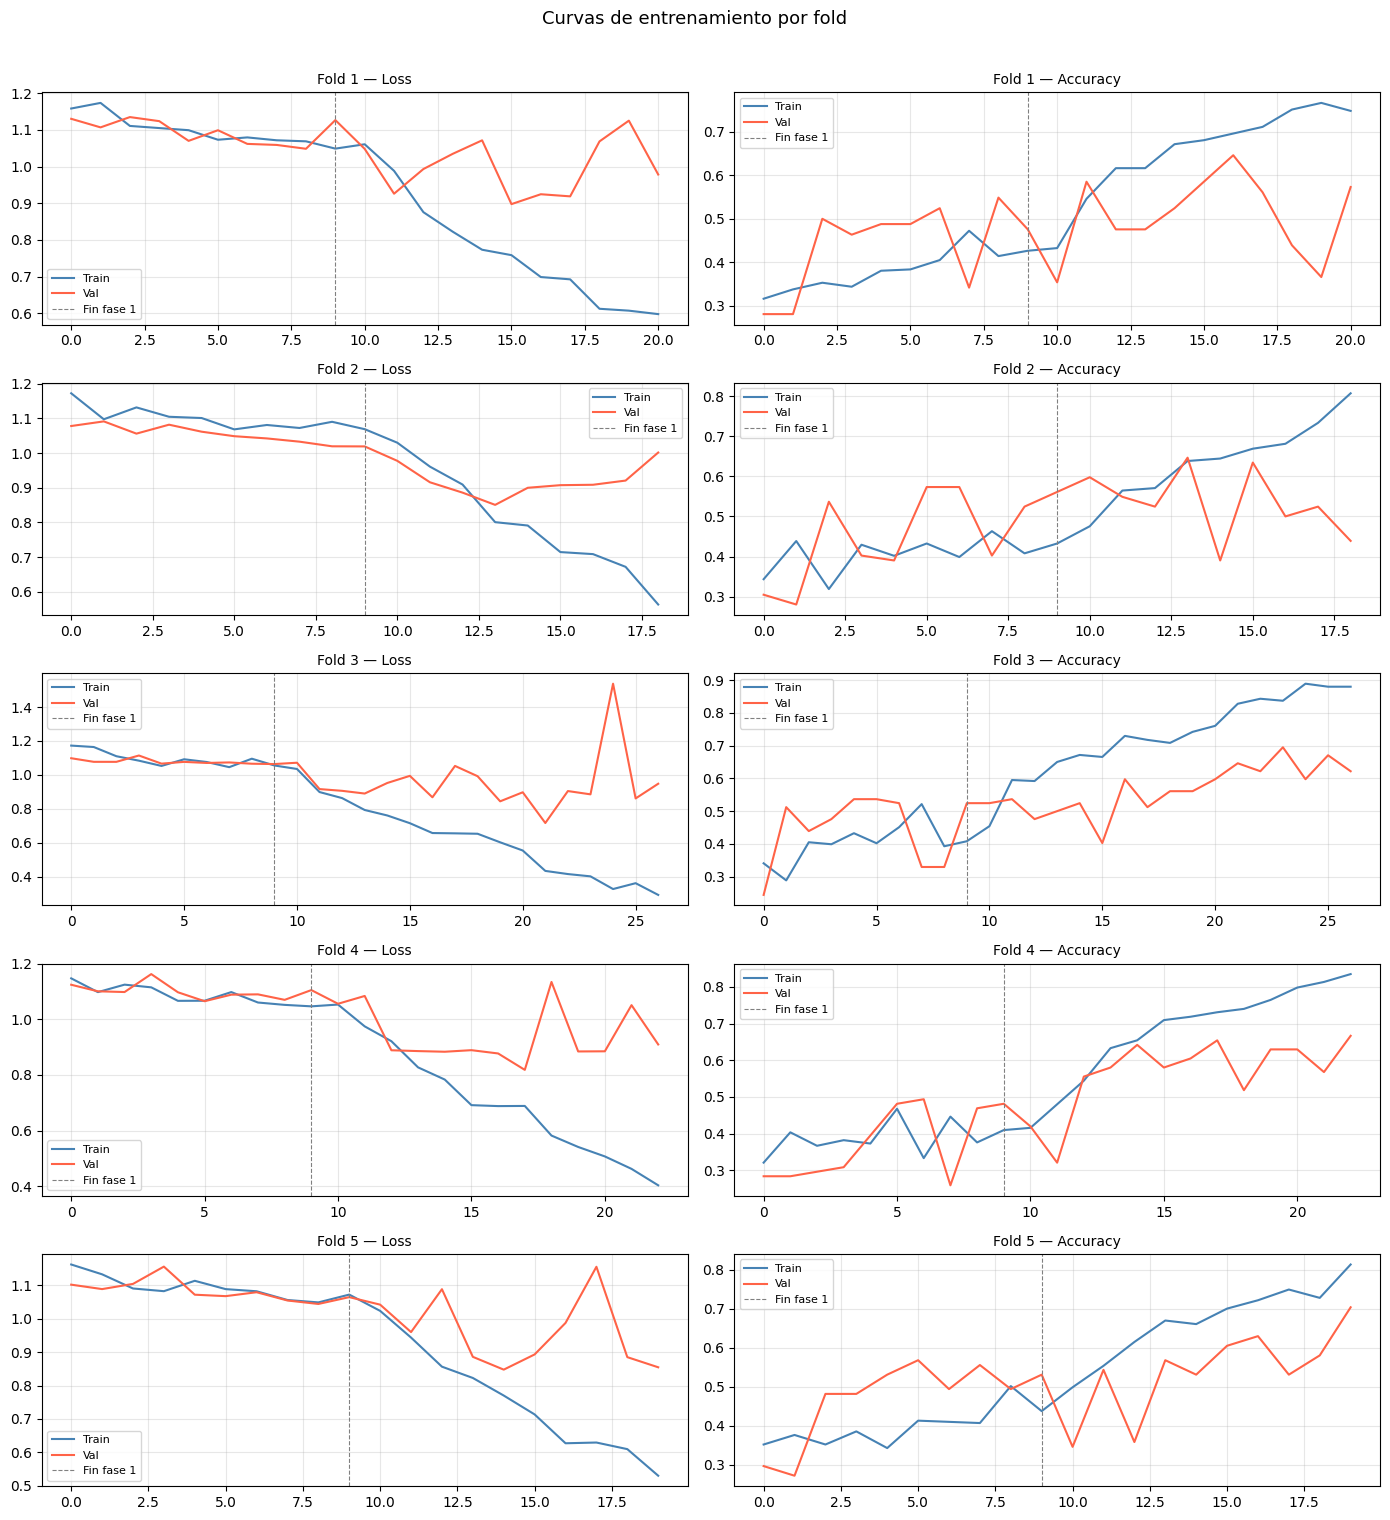

In [9]:
fig, axes = plt.subplots(N_FOLDS, 2, figsize=(14, N_FOLDS * 3))

for fold_idx, (h1, h2) in enumerate(fold_histories):
    tr_loss = h1['train_loss'] + h2['train_loss']
    vl_loss = h1['val_loss']   + h2['val_loss']
    tr_acc  = h1['train_acc']  + h2['train_acc']
    vl_acc  = h1['val_acc']    + h2['val_acc']
    pb      = len(h1['train_loss'])   # boundary entre fases

    for ax, (tr, vl), ylabel in zip(
        axes[fold_idx],
        [(tr_loss, vl_loss), (tr_acc, vl_acc)],
        ['Loss', 'Accuracy']
    ):
        ax.plot(tr, label='Train', color='steelblue')
        ax.plot(vl, label='Val',   color='tomato')
        ax.axvline(pb - 1, color='gray', linestyle='--', linewidth=0.8, label='Fin fase 1')
        ax.set_title(f'Fold {fold_idx+1} — {ylabel}', fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Curvas de entrenamiento por fold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Selección del mejor fold y evaluación en Test

Cargamos el checkpoint del fold con mayor AUC de validación  
y lo evaluamos sobre el **test set fijo** por primera y única vez.

In [10]:
best_fold = df_kfold.loc[df_kfold['val_auc'].idxmax(), 'fold']
print(f'Mejor fold: {best_fold} (AUC val = {df_kfold.loc[df_kfold["fold"]==best_fold, "val_auc"].values[0]:.4f})')

# Cargar modelo del mejor fold
best_model = build_densenet121(NUM_CLASSES, freeze_backbone=False).to(DEVICE)
best_model.load_state_dict(
    torch.load(MODELS_DIR / f'fold{best_fold}_best.pt', map_location=DEVICE)
)

# Class weights sobre todo el train+val para el criterion de test
cw_full   = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y)
criterion_test = nn.CrossEntropyLoss(
    weight=torch.tensor(cw_full, dtype=torch.float).to(DEVICE)
)

test_loss, test_acc, test_probs, test_preds, test_labels = evaluate(
    best_model, test_loader, criterion_test, DEVICE
)

print(f'\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}\n')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

Mejor fold: 3 (AUC val = 0.8441)

Test Loss: 0.9437 | Test Accuracy: 0.5490

              precision    recall  f1-score   support

        NORM       0.77      0.44      0.56        45
     Benigno       0.41      0.68      0.51        31
     Maligno       0.60      0.58      0.59        26

    accuracy                           0.55       102
   macro avg       0.59      0.57      0.55       102
weighted avg       0.62      0.55      0.55       102



## 10. Matriz de Confusión

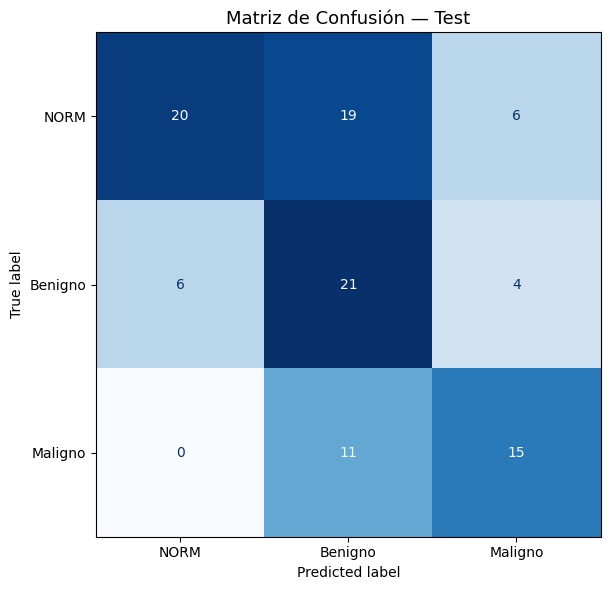

In [11]:
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Test', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Curvas ROC — One-vs-Rest

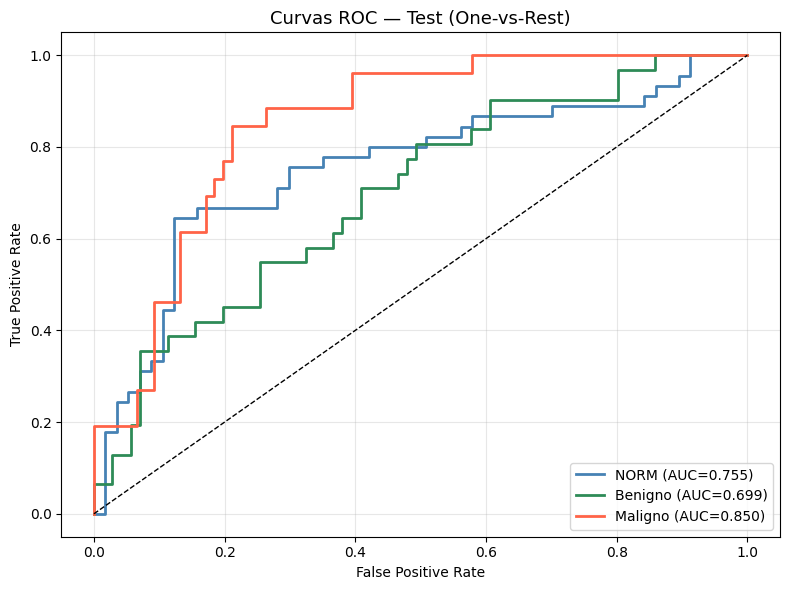

AUC macro (test): 0.7682


In [12]:
y_bin   = label_binarize(test_labels, classes=[0, 1, 2])
colors  = ['steelblue', 'seagreen', 'tomato']

fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Test (One-vs-Rest)', fontsize=13)
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_bin, test_probs, multi_class='ovr', average='macro')
print(f'AUC macro (test): {macro_auc:.4f}')

## 12. Visualización de predicciones individuales

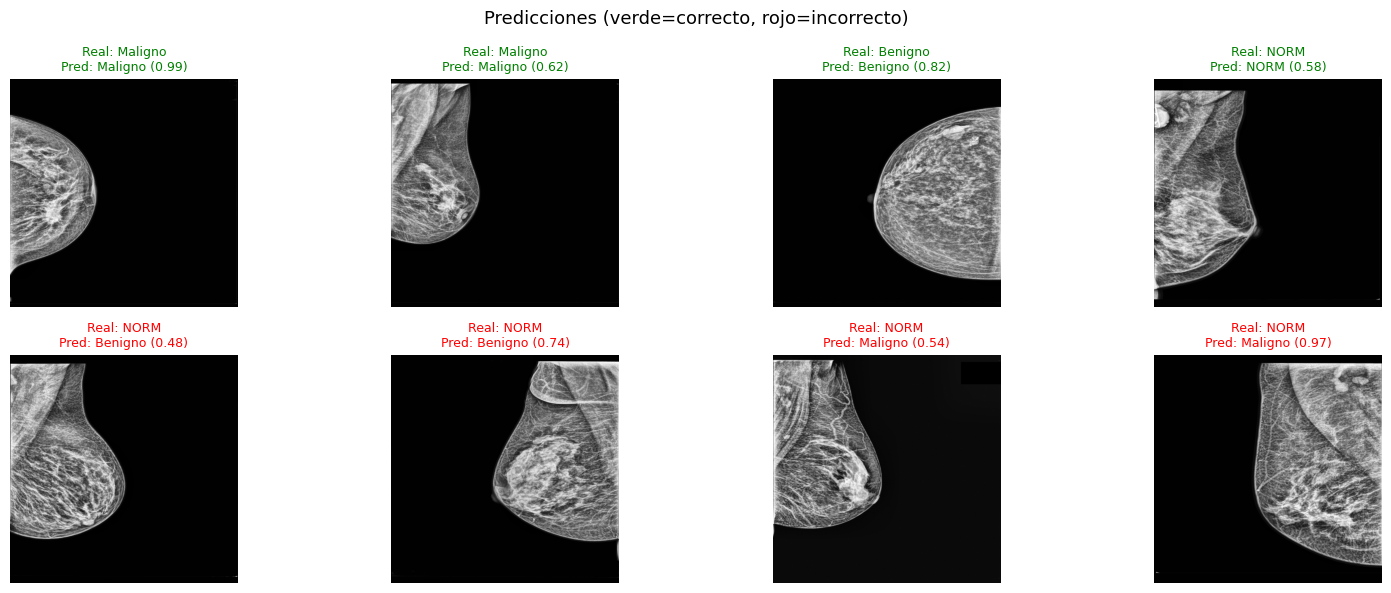

In [13]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)


@torch.no_grad()
def visualize_predictions(model, dataset, device, n=8):
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(2, n // 2, figsize=(16, 6))
    for ax, idx in zip(axes.flat, indices):
        img_t, true_lbl = dataset[idx]
        probs = torch.softmax(model(img_t.unsqueeze(0).to(device)), dim=1).squeeze().cpu().numpy()
        pred  = probs.argmax()
        img_np = denormalize(img_t).permute(1,2,0).numpy()[:,:,0]
        ax.imshow(img_np, cmap='gray')
        ax.set_title(
            f'Real: {CLASS_NAMES[true_lbl]}\nPred: {CLASS_NAMES[pred]} ({probs[pred]:.2f})',
            color='green' if pred == true_lbl.item() else 'red', fontsize=9
        )
        ax.axis('off')
    plt.suptitle('Predicciones (verde=correcto, rojo=incorrecto)', fontsize=13)
    plt.tight_layout()
    plt.show()

test_dataset = MammographyDataset(df_test, val_test_transform)
visualize_predictions(best_model, test_dataset, DEVICE)

## 13. Grad-CAM — visualización de activaciones

Grad-CAM muestra qué regiones de la imagen activaron la decisión del modelo.  
En mamografías permite verificar que el modelo atiende la lesión y no artefactos del borde.

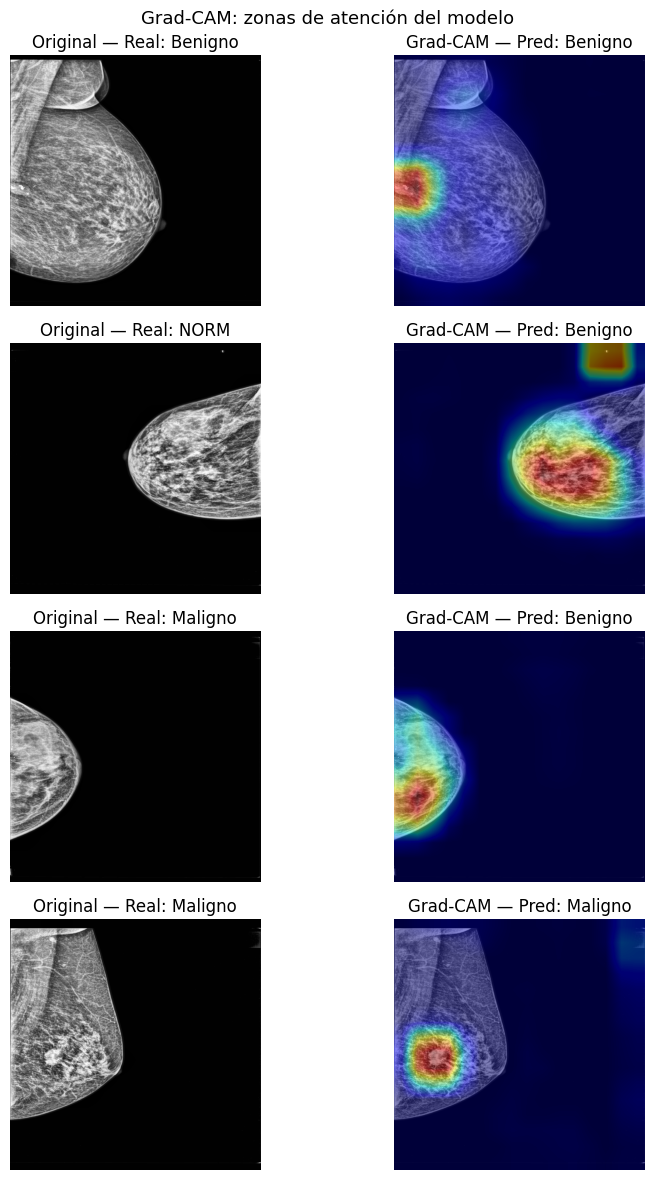

In [14]:
class GradCAM:
    """Grad-CAM sobre el último bloque denso de DenseNet121."""
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        layer = model.features.denseblock4
        layer.register_forward_hook(lambda m,i,o: setattr(self, 'activations', o.detach()))
        layer.register_full_backward_hook(lambda m,gi,go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        x   = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax().item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2,3], keepdim=True)
        cam     = torch.relu((weights * self.activations).sum(dim=1)).squeeze().cpu().numpy()
        cam     = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


grad_cam = GradCAM(best_model)

def show_gradcam(dataset, n=4):
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(n, 2, figsize=(9, n * 3))
    for row, idx in enumerate(indices):
        img_t, true_lbl = dataset[idx]
        cam, pred_idx   = grad_cam.generate(img_t)
        img_np = denormalize(img_t).permute(1,2,0).numpy()[:,:,0]
        axes[row,0].imshow(img_np, cmap='gray')
        axes[row,0].set_title(f'Original — Real: {CLASS_NAMES[true_lbl]}')
        axes[row,0].axis('off')
        axes[row,1].imshow(img_np, cmap='gray')
        axes[row,1].imshow(cam, cmap='jet', alpha=0.45)
        axes[row,1].set_title(f'Grad-CAM — Pred: {CLASS_NAMES[pred_idx]}')
        axes[row,1].axis('off')
    plt.suptitle('Grad-CAM: zonas de atención del modelo', fontsize=13)
    plt.tight_layout()
    plt.show()

show_gradcam(test_dataset)

## 14. Guardado de resultados para evaluación comparativa

In [15]:
np.save(RESULTS_DIR / 'clf_test_probs.npy',  test_probs)
np.save(RESULTS_DIR / 'clf_test_preds.npy',  test_preds)
np.save(RESULTS_DIR / 'clf_test_labels.npy', test_labels)

pd.DataFrame({
    'image_id':     df_test['image_id'].values,
    'true_label':   test_labels,
    'pred_label':   test_preds,
    'prob_NORM':    test_probs[:, 0],
    'prob_Benigno': test_probs[:, 1],
    'prob_Maligno': test_probs[:, 2],
}).to_csv(RESULTS_DIR / 'clf_predictions.csv', index=False)

# Guardar también resumen K-Fold
df_kfold.to_csv(RESULTS_DIR / 'clf_kfold_summary.csv', index=False)

print('Guardado en', RESULTS_DIR)
print('  clf_test_probs.npy / clf_test_preds.npy / clf_test_labels.npy')
print('  clf_predictions.csv')
print('  clf_kfold_summary.csv')

Guardado en ..\results
  clf_test_probs.npy / clf_test_preds.npy / clf_test_labels.npy
  clf_predictions.csv
  clf_kfold_summary.csv
